In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# EDA - Donnees e-commerce
une analyse exploratoire des donnees pour comprendre:
- la structure des tables
- la qualite des donnees (valeurs manquantes)
- la distribution des ventes
- les tendances temporelles
- le lien entre ventes et transactions

Objectif: preparer une base solide avant le feature engineering et la modelisation.

In [11]:
DATA_DIR = Path("../data/raw")

train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
stores = pd.read_csv(DATA_DIR / "stores.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv", parse_dates=["date"])
holidays = pd.read_csv(DATA_DIR / "holidays_events.csv", parse_dates=["date"])
oil = pd.read_csv(DATA_DIR / "oil.csv", parse_dates=["date"])

datasets = {
    "train": train,
    "stores": stores,
    "transactions": transactions,
    "holidays": holidays,
    "oil": oil,
}

for name, df in datasets.items():
    print(f"{name:12s} -> {df.shape[0]:>10,} lignes x {df.shape[1]} colonnes")

train        ->  3,000,888 lignes x 6 colonnes
stores       ->         54 lignes x 5 colonnes
transactions ->     83,488 lignes x 3 colonnes
holidays     ->        350 lignes x 6 colonnes
oil          ->      1,218 lignes x 2 colonnes


In [13]:
def quick_overview(name: str, df: pd.DataFrame) -> None:
    print(f"\n {name.upper()} ")
    print("Types:")
    print(df.dtypes.head(10))
    missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False)
    top_missing = missing_ratio[missing_ratio > 0].head(5)
    if top_missing.empty:
        print("Valeurs manquantes: aucune")
    else:
        print("Top valeurs manquantes (%):")
        print(top_missing)

quick_overview("train", train)
quick_overview("transactions", transactions)
quick_overview("oil", oil)


 TRAIN 
Types:
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object
Valeurs manquantes: aucune

 TRANSACTIONS 
Types:
date            datetime64[ns]
store_nbr                int64
transactions             int64
dtype: object
Valeurs manquantes: aucune

 OIL 
Types:
date          datetime64[ns]
dcoilwtico           float64
dtype: object
Top valeurs manquantes (%):
dcoilwtico    3.530378
dtype: float64


### Notes sur la verification
- Cette etape montre rapidement ou se trouvent les valeurs manquantes.
- Si une variable a beaucoup de NaN, il faudra choisir une strategie: suppression, imputation, ou modele robuste.
- Ici, l'objectif est de documenter la qualite des donnees avant de tracer les courbes.

In [14]:
print("Apercu des 5 premieres lignes de train")
display(train.head())

print("\nPeriode couverte par train:")
print(f"Date min: {train['date'].min()} | Date max: {train['date'].max()}")

print("\nCardinalites utiles:")
print(f"Nombre de magasins  : {train['store_nbr'].nunique()}")
print(f"Nombre de familles  : {train['family'].nunique()}")

print("\nStatistiques descriptives:")
display(train[["sales", "onpromotion"]].describe().T)

Apercu des 5 premieres lignes de train


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



Periode couverte par train:
Date min: 2013-01-01 00:00:00 | Date max: 2017-08-15 00:00:00

Cardinalites utiles:
Nombre de magasins  : 54
Nombre de familles  : 33

Statistiques descriptives:


,count,mean,std,min,25%,50%,75%,max
sales,3000888.0,357.775749,1101.997721,0.0,0.0,11.0,195.84725,124717.0
onpromotion,3000888.0,2.602770,12.218882,0.0,0.0,0.0,0.00000,741.0


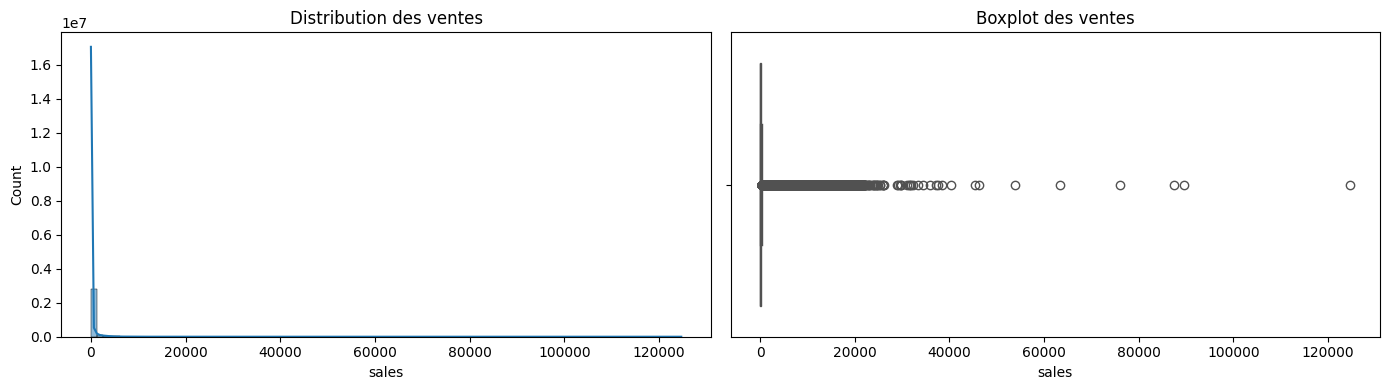

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(train["sales"], bins=100, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribution des ventes")
axes[0].set_xlabel("sales")

sns.boxplot(x=train["sales"], ax=axes[1], color="#ff7f0e")
axes[1].set_title("Boxplot des ventes")
axes[1].set_xlabel("sales")

plt.tight_layout()

In [ ]:
sales_daily = train.groupby("date", as_index=False)["sales"].sum()

plt.figure(figsize=(14, 4))
plt.plot(sales_daily["date"], sales_daily["sales"], color="#2ca02c")
plt.title("Ventes totales par jour")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

### Notes sur la tendance
- On observe ici l'evolution globale des ventes dans le temps.
- Les variations importantes peuvent correspondre a des promotions, jours feries ou changements de comportement client.
- Cette vue sert de base pour verifier la stabilite du signal avant modelisation.

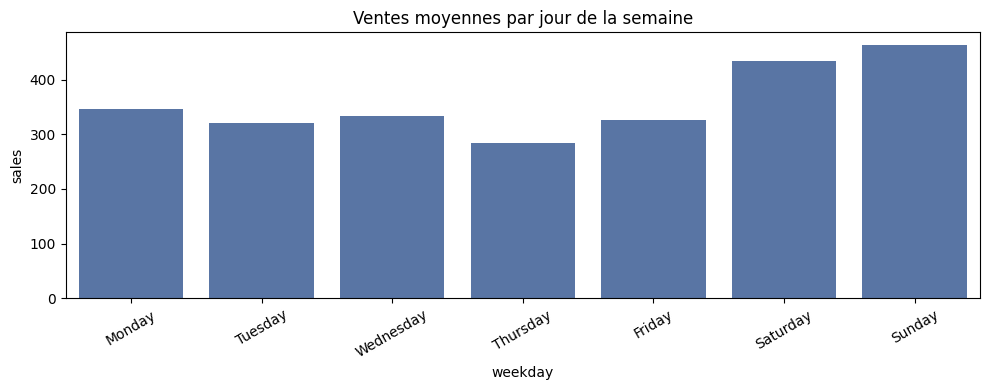

In [16]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sales_weekday = train.copy()
sales_weekday["weekday"] = sales_weekday["date"].dt.day_name()
weekday_avg = (
    sales_weekday.groupby("weekday", as_index=False)["sales"]
    .mean()
)
weekday_avg["weekday"] = pd.Categorical(weekday_avg["weekday"], categories=weekday_order, ordered=True)
weekday_avg = weekday_avg.sort_values("weekday")

plt.figure(figsize=(10, 4))
sns.barplot(data=weekday_avg, x="weekday", y="sales", color="#4c72b0")
plt.title("Ventes moyennes par jour de la semaine")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Correlation ventes/transactions: 0.677


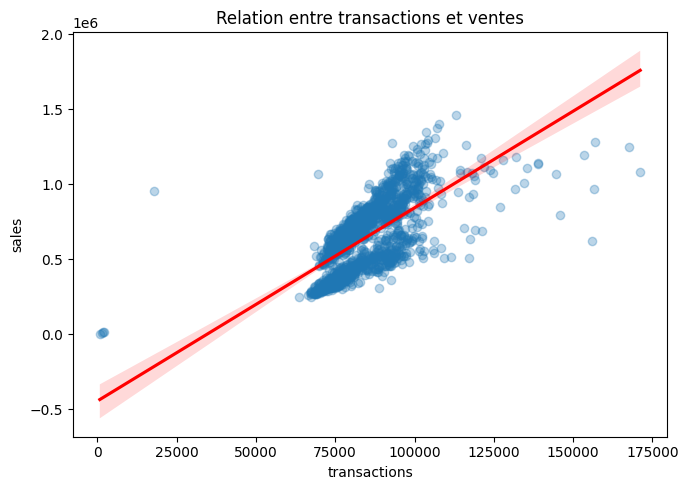

In [17]:
daily_sales = train.groupby("date", as_index=False)["sales"].sum()
daily_tx = transactions.groupby("date", as_index=False)["transactions"].sum()

merged = daily_sales.merge(daily_tx, on="date", how="inner")
corr = merged["sales"].corr(merged["transactions"])
print(f"Correlation ventes/transactions: {corr:.3f}")

plt.figure(figsize=(7, 5))
sns.regplot(data=merged, x="transactions", y="sales", scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.title("Relation entre transactions et ventes")
plt.tight_layout()
plt.show()

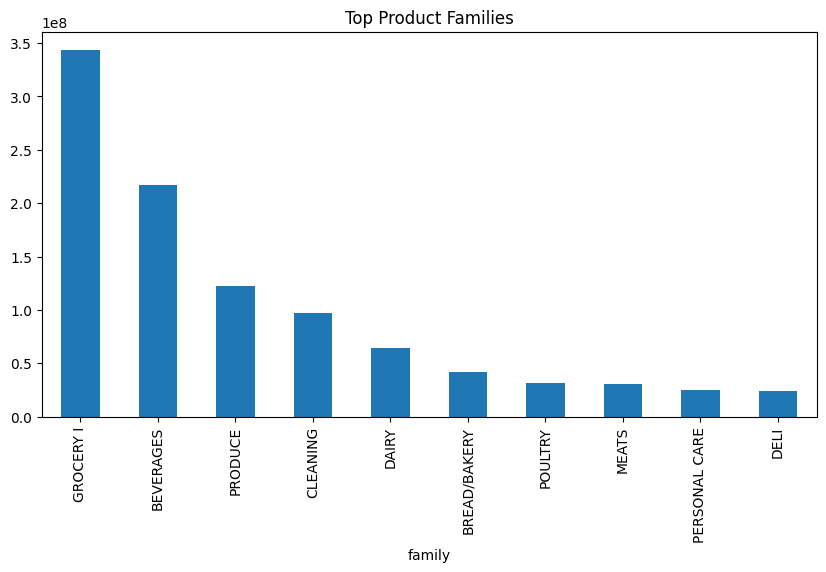

In [19]:
family_sales = train.groupby("family")["sales"].sum().sort_values(ascending=False)

family_sales.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top Product Families")
plt.show()

Est-ce que oil influence vraiment les ventes ?

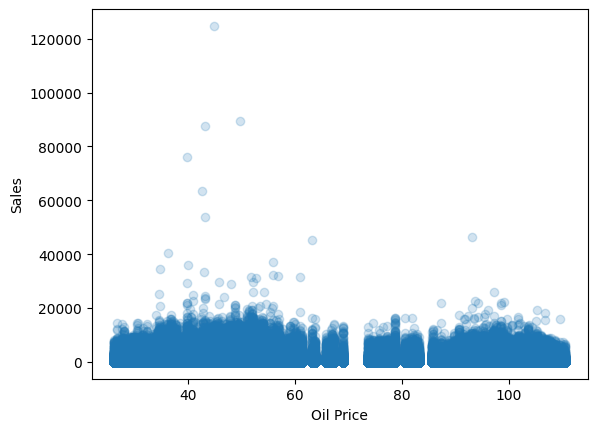

In [21]:
df = train.merge(oil, on="date")

plt.scatter(df["dcoilwtico"], df["sales"], alpha=0.2)
plt.xlabel("Oil Price")
plt.ylabel("Sales")
plt.show()